# Capítulo 3: Modelos probabilísticos discretos

<hr>

Códigos do livro: **Probabilidade e Estatística: Teoria, simulação e Dadados**<br>
Site: https://loja.uiclap.com/titulo/ua158988 <br>
Autor: Francisco A. Rodrigues<br>
https://sites.icmc.usp.br/francisco<br>
Universidade de São Paulo<br>
<hr>

In [1]:
# Pág. 83
import numpy as np
import random 
nsim = 10 # número de experimentos
nc = 0 # número de caras obtidas
moeda =['cara', 'coroa']
for i in range(0, nsim):
    saida = random.choice(moeda) # escolhe uma face
    print(saida)
    # se sair cara
    if(saida == 'cara'): 
        nc = nc + 1 # incrementa o contador de caras
print("Frequência de caras:", nc/nsim)

coroa
cara
coroa
cara
coroa
cara
coroa
cara
cara
cara
Frequência de caras: 0.6


In [2]:
# Pág. 88
import random
import numpy as np
# inicializa o gerador de números aleatórios
random.seed(10)

n = 12 # número de faces do dado
dado = np.arange(1,n+1)
print('dado:', dado)
X = [] # armazena os valores
ns = 1000 # número de simulações
for i in range(0,ns):
    # sorteia uma face do dado
    x = random.choice(dado)
    X.append(x)
print('Média = ', np.mean(X)) # calcula a média
print('Variância = ', np.var(X)) # calcula a variância


dado: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Média =  6.584
Variância =  11.896944


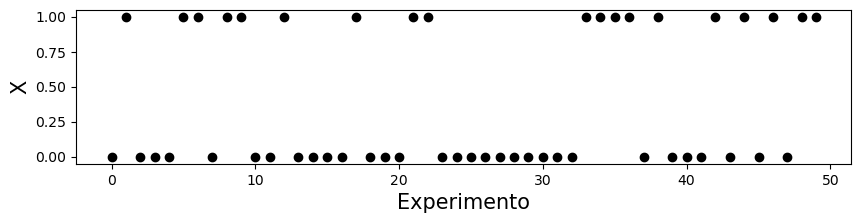

[0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1]


In [3]:
# Pág. 91
import numpy as np
from matplotlib import pyplot as plt
# inicializa o gerador de números aleatórios
np.random.seed(10)

n = 50 # número de experimentos
S = [] # lista que armazena as saídas
p = 0.4 # probabilidade de sucesso
for t in range(0,n):
    # gera uma saída: 0 ou 1
    if(np.random.uniform() < p):
        s = 1 # ocorre um sucesso
    else:
        s = 0 # ocorre uma falha
    S.append(s)
# mostra os resultados
plt.figure(figsize=(10,2))
plt.plot(range(0,n), S, 'ko')
plt.xlabel('Experimento', fontsize = 15)
plt.ylabel('X',fontsize = 15)
plt.show(True)
print(S)


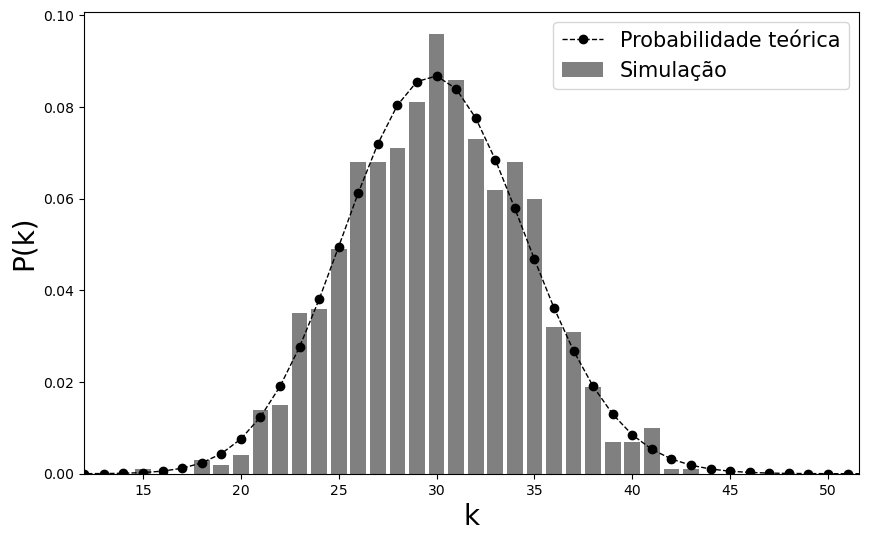

In [4]:
# Pág. 95
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import binom
import math
# inicializa o gerador de números aleatórios
np.random.seed(42)
n = 100 # número de lançamentos
p = 0.3 # probabilidade de sair cara
Pk = np.zeros(n)
vk = np.arange(0,n)
ns = 1000 # número de simulações
for j in range(0,ns): # realiza ns simulações
    S = 0 # número de sucessos
    for i in range(0,n): # para n lançamentos
        if(np.random.uniform() <= p): # se sair um sucesso
            S = S + 1
    Pk[S] = Pk[S] + 1
Pk=Pk/sum(Pk) # normaliza Pk

# mostra os resultados da simulações
plt.figure(figsize=(10,6))
plt.xlim(0.8*np.min(vk[Pk>0]),1.2*np.max(vk[Pk>0]))
plt.bar(vk, Pk, color ='gray', label='Simulação')

# mostra a curva teórica
Pkt = np.zeros(n+1) # valores teóricos da probabilidade
vkt = np.arange(0,n+1) # variação em k
for k in range(0,n+1): # varia de 0 até n
    C = (math.factorial(n)/(math.factorial(n-k)*math.factorial(k)))
    Pkt[k] = C*(p**k)*(1-p)**(n-k)
plt.plot(vkt, Pkt, color ='black', marker='o',linewidth=1,
         linestyle = 'dashed', label='Probabilidade teórica')
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)
plt.legend(fontsize = 15)
plt.show(True)

In [6]:
# Pág. 98
import numpy as np
# inicializa o gerador de números aleatórios
np.random.seed(101)
#probabilidades
pA = 0.2 # prob. do evento A
pB = 0.3 # prob. do evento B
pC = 0.5 # prob. do evento C
nsim = 1000 # número de simulações
ns = 0 # número de sucessos
for s in range(0,nsim):
    # número de vitórias de cada jogador
    nA = 0; nB = 0; nC = 0;
    # para os 6 jogos
    for n in range(0,6):
        num = np.random.uniform()
        if(num <= pA):
            nA = nA + 1
        else:
            if(num < pA + pB):
                nB = nB + 1
            else:
                nC = nC + 1
    # se A vence uma partida, B duas e C três
    if(nA == 1 and nB == 2 and nC == 3):
        ns = ns + 1
print('P(XA=1,XB=2,XC=3)=',ns/nsim)

P(XA=1,XB=2,XC=3)= 0.136


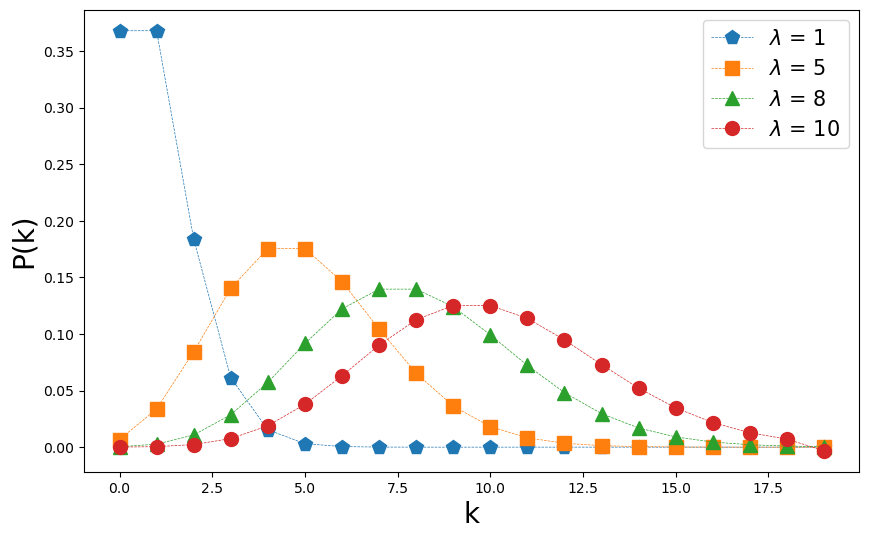

In [7]:
# Pág. 99
import numpy as np
import matplotlib.pyplot as plt
import math as math
kmax = 20 # valor máximo de k
plt.figure(figsize=(10,6))
vlb = [1,5,8,10] # lambdas
markers = ["o", "^", "s", "p"] # símbolos no gráfico
for lbd in vlb:
    px = []
    for k in np.arange(0,kmax):
        px.append((np.exp(-lbd)*lbd**k)/math.factorial(k))
    plt.plot(np.arange(0,kmax), px, 
             marker=markers.pop(), markersize=10, 
             linewidth=0.5,linestyle='dashed',
             label=r'$\lambda$ = '+str(lbd))
    plt.xlabel('k', fontsize = 20)
    plt.ylabel('P(k)',fontsize = 20)
plt.legend(fontsize = 15)
plt.show(True)


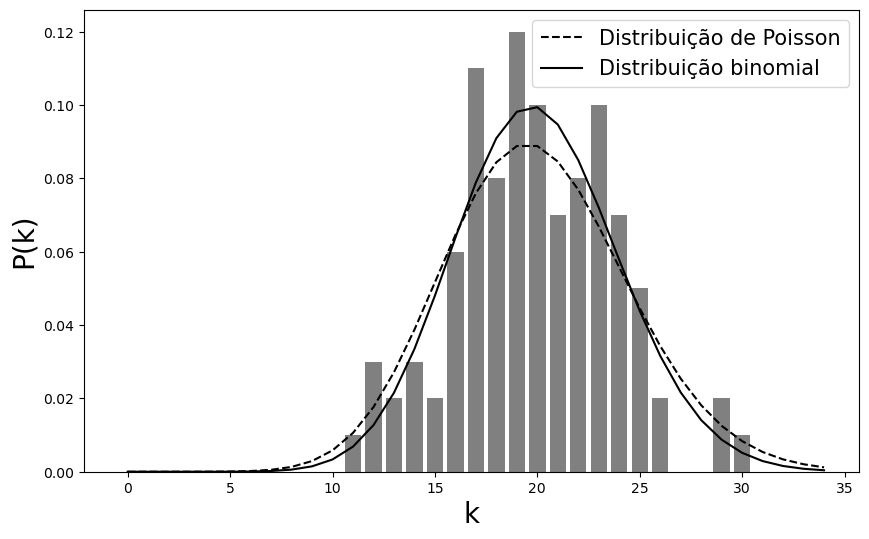

In [8]:
# Pág. 105
import numpy as np
from scipy.stats import poisson, binom
from matplotlib import pyplot as plt
# inicializa o gerador de números aleatórios
np.random.seed(101)

N = 100 # número de vértices
lbd = 20 # número médio de conexões
p = lbd/(N-1) # probabilidade de conectar dois vértices
# cria a matriz de adjacência
A = np.zeros((N,N)) 
for i in range(0,N):
    for j in range(i+1,N):
        if np.random.uniform() <= p:
            # conecta os vértices i e j
            A[i,j] = 1
            A[j,i] = 1
# lista com o número de conexões de cada vértice
vk = np.sum(A, axis = 0,dtype = np.uint8)
# armazena a distribuição de probabilidade
Pk = np.zeros(int(np.max(vk)+1))
for k in vk:
    Pk[k] = Pk[k]+1
Pk = Pk/np.sum(Pk)

# mostra a distribuição de probabilidade
plt.figure(figsize=(10,6))
plt.bar(np.arange(0,np.max(vk)+1), Pk, color = 'gray')
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)

# mostra a distribuição teórica de Poisson
x = np.arange(0,np.max(vk)+5)
px = poisson((N-1)*p)
plt.plot(x,px.pmf(x), '--', color ='black', 
         label='Distribuição de Poisson')

# Mostra a distribuição teórica binomial
pb = binom((N-1),p)
plt.plot(x,pb.pmf(x), '-', color = 'black', 
         label='Distribuição binomial')
plt.legend(fontsize = 15)
plt.show(True)

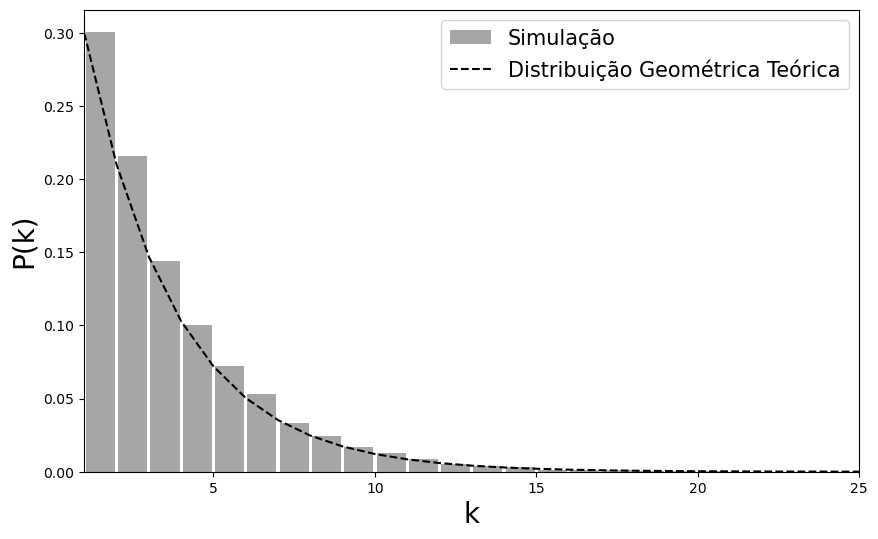

In [9]:
# Pág. 108
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import geom
# inicializa o gerador de números aleatórios
np.random.seed(10)

p = 0.3 # probabilidade de um sucesso
X = [] # armazena o número de experimentos
ns = 10000 # número de simulações
for i in range(0,ns):# para ns simulações
    k = 0 # número de experimentos
    s = False # variável que indica uma falha
    while s == False: # enquanto não sair um sucesso
        # sorteia um número entre 0 e 1
        r = np.random.uniform() 
        if(r <= p): # se for um sucesso
            s = True # indica um sucesso
        k = k + 1 # incrementa o número de experimentos
    X.append(k) # guarda o número de experimentos

k = np.arange(0, np.max(X))
# mostra os resultados da simulação
plt.figure(figsize=(10,6))
count, bins, ignored = plt.hist(X, bins=k, density=True, 
                                color='gray',alpha=0.7,
                                rwidth=0.9, 
                                label='Simulação')
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)

# mostra a distribuicao teórica
x = np.arange(1,np.max(k)+5)
px = geom(p)
plt.plot(x,px.pmf(x), '--', color ='black', 
         label='Distribuição Geométrica Teórica')
plt.xlim(1,max(x))
plt.legend(fontsize =15)
plt.show(True)

In [10]:
# Pág. 109
import numpy as np
# inicializa o gerador de números aleatórios
np.random.seed(10)
p = 9/36 # probabilidade de sucesso
ns = 1000 # número de simulações
x = 0 # número de experimentos favoráveis
for s in range(0,ns):
    k = 0 # número de retiradas
    sucesso = False
    # enquanto não sair a bola preta, faça
    while sucesso == False:
        if(np.random.uniform() < p):
            sucesso = True
        k = k + 1
    if(k > 6): 
        # se foi necessário mais do que 6 retiradas
        x = x + 1
print('P(X > 6) = ', x/ns)

P(X > 6) =  0.165


In [12]:
# Pág. 112
import numpy as np
# inicializa o gerador de números aleatórios
np.random.seed(13)
p = 0.04
ns = 10000 # número de simulações
X = [] # número de encontros necessários
for s in range(0,ns):
    k = 0 # número de encontros
    sucesso = False
    # enquanto não encontrar um professor
    while sucesso == False:
        if(np.random.uniform() < p):
            sucesso = True
        k = k + 1
    # guarda o número de encontros
    X.append(k)
print('Número médio de encontros = ', np.mean(X))
print('Variância = ', np.var(X))

Número médio de encontros =  24.8473
Variância =  599.17678271


In [13]:
# Pág. 116
import numpy as np
import random as random
# inicializa o gerador de números aleatórios
random.seed(10)

N = 25 # número total de elementos
N1 = 4 # número de elementos do tipo 1
N2 = N-N1 # número de elementos do tipo 2
n = 5 # número de objetos selecionados sem reposição
# geramos um vetor com os itens dos tipos 1 e 2
v = [1]*N1 + [2]*N2
# simulamos s retiradas
s = 100 # número de simulações
k = 0 # conta os sucessos
x = 2 # número de objetos do tipo 1 sorteados
for i in range(0,s):
    # sorteia n itens sem reposição
    itens = random.sample(v,n) 
    # se há no máximo 2 itens do tipo 1
    if(itens.count(1) <= x):
        k = k + 1
print("Probabilidade = ", k/s)       

Probabilidade =  0.97


In [14]:
# Pág. 119
import random as random
random.seed(101)
urna = ['B','B','B','B','B','B','B','B','P','P','P','P']
n = 5
k = 4
ns = 100 # número de simulações
x = 0 # número de experimentos favoráveis
for s in range(0,ns):
    sucessos = 0
    for i in range(0,n):
        bola_retirada = random.choice(urna)
        if(bola_retirada == 'B'):
            sucessos = sucessos + 1
    if(sucessos >= k):
        x = x + 1
print("Probabilidade = ", x/ns)

Probabilidade =  0.47


In [15]:
# Pág. 120
import numpy as np
# inicializa o gerador de números aleatórios
np.random.seed(101)

p = 0.7 # probabilidade de um sucesso
k = 0 # número de experimentos
r = 3 # número de sucessos para aceitar o app
ns = 1000 # número de simulações
x = 0 # número de experimentos favoráveis
for s in range(0,ns):
    sucessos = 0
    k = 0 # número de testes para termos 3 sucessos
    while sucessos < r:
        if(np.random.uniform() < p):
            sucessos = sucessos + 1
        k = k + 1
    # se ocorrem 3 sucessos em 5 tentativas, 
    # sendo a última um sucesso, incrementa x
    if(k == 5): 
        x = x + 1
print("P(X = 5) =",x/ns)

P(X = 5) = 0.177
